# Project 3a: Sentiment/Bias Analysis of Cyber Threat Intelligence Reports

#### Student Name: Isaac Kone
#### Student ID: 501280479

# Introduction:

Cyber threat intelligence reports play a crucial role in shaping how the cybersecurity community understands and addresses key issues, threat actors, and nation-state activities. These reports are foundational in framing the discourse around cyber threats, making them an essential subject of analysis.

# Project Overview:

In this project, you will use Natural Language Processing (NLP) to perform a sentiment analysis on cyber threat intelligence reports. Your task is to analyze how these reports cover various cyber threats, focusing on the sentiment and potential biases present in the documents. Proficiency in Python is required for this project.

**Do not use Pie Charts or Ring/Doughnut Charts for your graphs. Unless you wish to reduce your grade.**

## Objectives
* **Analyze Sentiment:** Conduct a sentiment analysis to determine the tone of the threat intelligence reports.
* **Identify Biases:** Examine the reports for any biases and analyze how these biases influence the sentiment.
* **Visualize Data:** Create at least three graphs to illustrate the following:
    - The overall sentiment of the documents.
    - A comparison of bias versus sentiment (choose one type of bias).
    - A visualization of the identified bias.

## Requirements
* **Data Collection:** You will be provided with a list of cyber threat intelligence reports to analyze. Additionally, you are required to find and analyze three more articles that are similar to the provided ones.
* **Graph Creation:** Be creative with your visualizations. While bar charts are acceptable, avoid using pie charts. Experiment with different types of graphs to effectively convey your findings.
* **Support and Collaboration:** If you encounter any challenges or have concerns about the project's scope, proactively seek support and collaborate with your peers or instructors.
s
URL.**

## Deliverables
* A detailed analysis report of your findings.
* At least three graphs representing your data.
* A summary of any biases identified and their potential impact on the sentiment of the reports.
.


## Skills and Benefits:

**Natural Language Processing (NLP) Proficiency:**

Gain hands-on experience with NLP techniques and libraries such as NLTK, spaCy, or TextBlob, essential for processing and analyzing textual data.

**Data Analysis and Visualization:**
 - Develop skills in analyzing large datasets and creating informative visualizations using tools like Matplotlib, Seaborn, or Plotly. This is crucial for presenting findings in a clear and impactful manner.

**Python Programming:**
 - Enhance your Python programming skills, particularly in the context of data science and cybersecurity. Proficiency in Python is a valuable asset in many tech-related fields.

**Understanding Cyber Threat Intelligence:**
 - Deepen your knowledge of cyber threat intelligence reports, understanding their structure, content, and the role they play in cybersecurity. This knowledge is essential for anyone pursuing a career in cybersecurity.

**Bias and Sentiment Analysis:**
 - Learn to identify and analyze biases and sentiments in text, which is an important skill in many fields, including cybersecurity, marketing, and social sciences.

**Critical Thinking and Problem-Solving:**
 - Develop critical thinking and problem-solving skills as you analyze complex reports, identify biases, and determine the sentiment. This project encourages you to think deeply about the implications of your findings.

**Project Management and Collaboration:**
 - Improve your project management and collaboration skills by working on a comprehensive project with multiple deliverables. This includes planning, executing, and presenting your findings, as well as seeking support and feedback when necessary.

By completing this project, you'll not only gain technical skills but also a deeper understanding of the cybersecurity landscape, making you better prepared for future challenges in this field.

I look forward to seeing your insightful analyses and creative visualizations. Good luck, and happy analyzing!

## Project 3: Due on July 31, 2025 (18:00).

#### Libraries used:

This section loads all required libraries.

In [9]:
!pip install spacy python-docx pdfplumber textblob pandas numpy seaborn scikit-learn ipykernel #install necessary dependencies
!python -m ipykernel install --user --name=venv #try to ensure the correct kernel is being used 
!python -m spacy download en_core_web_md #downloading model
!which python3 #helpful for debugging
from IPython.display import display, Image
import spacy #nlp
from spacy.tokens.doc import Doc
from spacy.util import minibatch
from spacy.training.example import Example
from textblob import TextBlob
import pandas as pd
from docx import Document
import pdfplumber
import os
from collections import Counter
from dateutil.parser import parse as parse_date
import re
import numpy as np
import seaborn as sns
from IPython.display import display
from spacy.lang.en.stop_words import STOP_WORDS
from matplotlib import pyplot as plt
import requests

Installed kernelspec venv in /home/z/.local/share/jupyter/kernels/venv
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 2.0 MB/s  0:00:17 eta 0:00:010:01:02m
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
/home/z/Documents/courses/ccps633/project3_files/venv/bin/python3


#### Set Data Path:
This sction contains the path to where the data set.

In [16]:
# Set paths
main_dir = 'D:/'
data_dir = main_dir +'Python Data/'
output_dir = main_dir +'Reports/'

# Set working directory
os.chdir(main_dir)

# Remove annoying error
pd.options.mode.chained_assignment = None  # default='warn'
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

#load model
nlp = spacy.load("en_core_web_md")


FileNotFoundError: [Errno 2] No such file or directory: 'D:/'

#### Functions:

In [3]:


def analyze_bias_signals(row: dict) -> str:
    """Evaluate bias signals based on sentiment, repetition, and moral framing."""
    display("Analyzing bias signals...")
    notes = []
    tokens = row["tokens"]
    text = row["text"]
    title = row["title"]
    named_entities = row["named_entities"]
    title_lower = title.lower()
    title_polarity, title_subjectivity = row["title_sentiment"]
    text_polarity = row["sentiment_polarity"]

    result = {
        "notes": notes,
        "top_tokens": [],
        "mfd_dominant": None
    }

    # === 1. Title subjectivity
    if title_subjectivity > 0.6:
        notes.append(f"The title appears highly subjective (subjectivity score: {title_subjectivity:.2f}), which may indicate sensationalized framing.")
    elif title_subjectivity < 0.3:
        notes.append(f"The title appears relatively objective (subjectivity score: {title_subjectivity:.2f}), suggesting a more neutral framing.")

    # === 2. Title sentiment intensity
    if abs(title_polarity) >= 0.5:
        tone = "positive" if title_polarity > 0 else "negative"
        notes.append(f"The title expresses a strong {tone} sentiment (polarity score: {title_polarity:.2f}).")
    elif abs(title_polarity) < 0.1:
        notes.append(f"The title is mostly neutral in tone (polarity score: {title_polarity:.2f}).")

    # === 3. Sentiment contrast between title and body
    polarity_diff = abs(title_polarity - text_polarity)
    if polarity_diff >= 0.4:
        notes.append(
            f"There is a significant difference between the title's sentiment (polarity {title_polarity:.2f}) "
            f"and the main text's sentiment (polarity {text_polarity:.2f}), which may reflect selective or misleading framing."
        )

    # === 4. Framing bias based on named entities in title
    classified_ne = classify_entities(named_entities)
    who = classified_ne.get("WHO", [])
    where = classified_ne.get("WHERE", [])
    when = classified_ne.get("WHEN", [])
    what = classified_ne.get("WHAT", [])

    geo_labels = {"ORG", "GPE", "NORP"}
    geo_entities = set([ent for ent, label in named_entities if label in geo_labels])

    if title_polarity < -0.1:
        if len(geo_entities) >= 2:
            notes.append("Multiple geopolitical or institutional actors are mentioned — this may suggest inter-state conflict or strategic tension.")
        for category, entities in {"WHO": who, "WHAT": what, "WHERE": where, "WHEN": when}.items():
            for ent in entities:
                if ent.lower() in title_lower:
                    notes.append(f"The {category.lower()} '{ent}' appears in a title with adverse sentiment, which may affect reader perception.")
    elif title_polarity > 0.1:
        if len(geo_entities) >= 2:
            notes.append("Multiple geopolitical or institutional actors are mentioned — this may indicate international collaboration, joint action, or shared strategic interests.")
        for category, entities in {"WHO": who, "WHAT": what, "WHERE": where, "WHEN": when}.items():
            for ent in entities:
                if ent.lower() in title_lower:
                    notes.append(f"The {category.lower()} '{ent}' appears in a title with favorable sentiment, which may shape reader interpretation positively.")

    # === 5. Repetition analysis (tokens and entities)
    filtered_tokens = [tok for tok in row["tokens"] if tok not in STOP_WORDS]
    token_counts = Counter(filtered_tokens)
    top_tokens = token_counts.most_common(10)
    result["top_tokens"] = top_tokens  # For visualizations

    # Add token-level repetition note
    repeated_str = ", ".join([f"{tok} ({count})" for tok, count in top_tokens if count > 4])
    if repeated_str:
        notes.append(f"The following terms are frequently repeated, indicating narrative emphasis: {repeated_str}.")

    # Named entity repetition (case insensitive)
    ner_counts = Counter(ent for ent, _ in named_entities)
    repeated_entities = [f"{k} ({v})" for k, v in ner_counts.items() if v > 3]
    if repeated_entities:
        notes.append(f"The following entities are repeatedly emphasized: {', '.join(repeated_entities)}.")

    return result

def detect_context(row: dict) -> str:
    display("Detecting context (with timeline)...")
    notes = []
    classified_ne = classify_entities(row["named_entities"])

    who = classified_ne.get("WHO", [])
    where = classified_ne.get("WHERE", [])
    when = classified_ne.get("WHEN", [])
    what = classified_ne.get("WHAT", [])

    # 1. Contextual summary notes
    if who:
        notes.append(f"Named actors mentioned include: {', '.join(who)}.\n")
    if where:
        notes.append(f"Geographic locations involved include: {', '.join(where)}.\n")
    if when:
        notes.append(f"Relevant dates referenced include: {', '.join(when)}.\n")
    if what:
        notes.append(f"Key topics or events discussed include: {', '.join(what)}.\n")

    # Timeline detection from date entities
    raw_dates = [ent for ent, label in row["named_entities"] if label == "DATE"]
    parsed_dates = []
    for d in raw_dates:
        try:
            if re.search(r'\d{4}|\d{2}', d):  # year or number indicator
                parsed = parse_date(d, fuzzy=True)
                if parsed:
                    # Convert to naive datetime by removing tzinfo
                    parsed = parsed.replace(tzinfo=None)
                    parsed_dates.append((d, parsed))
        except Exception:
            continue

    # Sort safely
    if parsed_dates:
        sorted_dates = sorted(parsed_dates, key=lambda x: x[1])
        if len(sorted_dates) >= 3:
            notes.append(
                f"The text refers to multiple dates, forming a narrative timeline from {sorted_dates[0][0]} to {sorted_dates[-1][0]}."
            )

    return " ".join(notes)






#### Load Data:
This section load the file.

In [4]:

def load_data(data_dir: str) -> pd.DataFrame:
    """Load and process text documents into a structured DataFrame."""
    display("Loading and processing data...")
    data = os.listdir(data_dir)
    columns = [
        "title", "text", "cleaned_text", "tokens",
        "sentiment_polarity", "sentiment_subjectivity", "title_sentiment",
        "named_entities", "section_labels", 
        "context_notes", "general_sentiment", "top_tokens", "mfd_data"
    ]
    rows = []

    for file in data:
        if file.lower().endswith((".doc", ".docx", ".pdf", ".txt")):
            display(f"Processing file: {file}...")
            row = {}
            title = file.replace("_", " ").replace(".docx", "").title()
            text = read_document(os.path.join(data_dir, file))
            doc = nlp(text)

            # Core preprocessing
            row["title"] = title
            row["text"] = text
            row["cleaned_text"] = clean_text(doc)
            row["tokens"] = tokenize(doc)
            row["named_entities"] = ner(doc.ents)

            # Sentiment
            row["sentiment_polarity"] = smp(text)
            row["sentiment_subjectivity"] = sms(text)
            row["title_sentiment"] = (smp(title), sms(title))

            #analysis
            row["context_notes"] = detect_context(row)
            bias_data = analyze_bias_signals(row)
            row["general_sentiment"] = "; ".join(bias_data["notes"])
            row["top_tokens"] = bias_data["top_tokens"]
            row["mfd_dominant"] = bias_data["mfd_dominant"]

            rows.append(row)

    return pd.DataFrame(rows, columns=columns)

#### Data Wrangling:

This secion contains the required functions used to clean and prepare the data

In [5]:
def download_pdf(url: str, save_dir: str = data_dir):
    """
    Download a single PDF file from the given URL and save it into the specified directory.
    """
    filename = url.split("/")[-1]
    save_path = os.path.join(save_dir, filename)

    print(f"Downloading: {url}")
    try:
        response = requests.get(url)
        response.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(response.content)
        print(f"Saved to: {save_path}")
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        
def clean_text(doc:Doc) -> str:
    """Return a lemmatized and lowercased string without stopwords or punctuation."""
    display("Cleaning text...")
    return " ".join([token.lemma_.lower() for token in doc if not token.is_stop and token.is_alpha])

def tokenize(doc:Doc) -> list:
    """Return a list of lemmatized lowercase tokens excluding punctuation and spaces."""
    display("Tokenizing text...")
    return [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]

def smp(text:str) -> float:
    """Return sentiment polarity score of the input text using TextBlob."""
    display("Calculating sentiment polarity...")
    blob = TextBlob(text)
    return blob.sentiment.polarity

def sms(text:str) -> float:
    """Return sentiment subjectivity score of the input text using TextBlob."""
    display("Calculating sentiment subjectivity...")
    blob = TextBlob(text)
    return blob.sentiment.subjectivity

def ner(ents:tuple) -> set[tuple]:
    """Extract named entities and their labels from spaCy Doc object."""
    display("Extracting named entities...")
    return set((ent.text.lower().strip(), ent.label_) for ent in ents)

def classify_entities(entities: list[tuple[str, str]]) -> dict:
    """Classify named entities into WHO, WHERE, WHEN, WHAT categories."""
    display("Classifying named entities...")
    role_map = {
        "WHO": {"PERSON", "ORG", "NORP"},
        "WHERE": {"GPE", "LOC", "FAC"},
        "WHEN": {"DATE", "TIME"},
        "WHAT": {"EVENT", "PRODUCT", "LAW"},
    }
    grouped = {"WHO": [], "WHERE": [], "WHEN": [], "WHAT": [], "WHY": [], "HOW": []}
    
    for text, label in entities:
        for role, label_set in role_map.items():
            if label in label_set:
                grouped[role].append(text)
    return grouped
    
def read_document(file:str) -> str:
    """Read and extract text from DOCX, PDF, or TXT files."""
    display(f"Reading document: {file}...")
    if file.endswith(".pdf"):
        with open(file, 'rb') as f:
            with pdfplumber.open(f) as pdf:
                text = ""
                for page in pdf.pages:
                    text += page.extract_text()
        return text

    if file.endswith(("doc", "docx")):
        doc = Document(file)
        full_text = []
        for para in doc.paragraphs:
            full_text.append(para.text)
        text = '\n'.join(full_text)
        return text

    if file.endswith("txt"):
        with open(file, 'r') as f:
            text =  f.read()
        return text

#### Graphs:

In [14]:
def plot_bias_report(df, save_path=None):
    """
    Generate advanced bias/sentiment visualizations for threat intel reports.
    Optionally save as PNG if save_path is provided.
    """
    display("Generating advanced visualizations...")

    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    fig.suptitle("Cyber Threat Report Bias & Sentiment Analysis", fontsize=18, fontweight='bold')

    # === Plot 1: Sentiment polarity vs subjectivity
    sns.scatterplot(
        data=df,
        x="sentiment_polarity",
        y="sentiment_subjectivity",
        hue="title",
        ax=axes[0, 0],
        palette="tab10",
        legend=False
    )
    axes[0, 0].set_title("Sentiment Polarity vs Subjectivity", fontsize=14)
    axes[0, 0].axhline(0.5, ls='--', color='gray')
    axes[0, 0].axvline(0, ls='--', color='gray')
    axes[0, 0].set_xlim(-1, 1)
    axes[0, 0].set_ylim(0, 1)

    # === Plot 2: Top Tokens Barplot
    all_tokens = []
    for tokens in df["top_tokens"]:
        all_tokens.extend([tok for tok, count in tokens])
    token_freq = dict(Counter(all_tokens))
    token_items = sorted(token_freq.items(), key=lambda x: x[1], reverse=True)[:15]
    tokens, counts = zip(*token_items)
    sns.barplot(x=list(counts), y=list(tokens), ax=axes[0, 1], palette="Blues_d")
    axes[0, 1].set_title("Top 15 Repeated Tokens", fontsize=14)

    # === Plot 3: Polarity Histogram
    sns.histplot(df["sentiment_polarity"], bins=20, kde=True, ax=axes[1, 0], color='skyblue')
    axes[1, 0].set_title("Polarity Distribution", fontsize=14)
    axes[1, 0].set_xlabel("Sentiment Polarity")

    # === Plot 4: Polarity Comparison (Title vs Body)
    title_polarities = df["title_sentiment"].apply(lambda x: x[0])
    text_polarities = df["sentiment_polarity"]
    sns.scatterplot(x=title_polarities, y=text_polarities, ax=axes[1, 1], color="darkred")
    axes[1, 1].plot([-1, 1], [-1, 1], ls="--", color="gray")  # Diagonal line
    axes[1, 1].set_title("Title vs Body Polarity", fontsize=14)
    axes[1, 1].set_xlabel("Title Polarity")
    axes[1, 1].set_ylabel("Body Polarity")

    # === Plot 5: Named Entity Heatmap
    from collections import defaultdict
    entity_freq = defaultdict(int)
    for doc_ents in df["named_entities"]:
        for ent, label in doc_ents:
            key = f"{ent.strip().lower()} ({label})"
            entity_freq[key] += 1
    top_ents = dict(sorted(entity_freq.items(), key=lambda x: x[1], reverse=True)[:15])
    sns.heatmap(
        np.array(list(top_ents.values())).reshape(-1, 1),
        yticklabels=list(top_ents.keys()),
        ax=axes[2, 0],
        cmap="Reds",
        annot=True,
        cbar=False
    )
    axes[2, 0].set_title("Top Named Entities (Heatmap)")
    axes[2, 0].set_xticks([])
    axes[2, 0].set_ylabel("")

    # === Plot 6: Correlation Heatmap
    df_corr = df[["sentiment_polarity", "sentiment_subjectivity"]].copy()
    df_corr["title_polarity"] = df["title_sentiment"].apply(lambda x: x[0])
    sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", ax=axes[2, 1])
    axes[2, 1].set_title("Correlation of Sentiment Metrics")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        fig.savefig(save_path, dpi=300)
        display(f"Saved plot to: {save_path}")
    else:
        plt.show()


Downloading: https://canadiancybersecuritynetwork.com/hubfs/CS-Report-CCN-2025-All-v10.pdf
Saved to: ./CS-Report-CCN-2025-All-v10.pdf
Downloading: https://go.recordedfuture.com/hubfs/reports/cta-2023-1107.pdf
Saved to: ./cta-2023-1107.pdf
Downloading: https://www.clairfield.com/wp-content/uploads/2025/06/Clairfield-International-cybersecurity-report-2024-2025.pdf
Saved to: ./Clairfield-International-cybersecurity-report-2024-2025.pdf


'Loading and processing data...'

'Processing file: Clairfield-International-cybersecurity-report-2024-2025.pdf...'

'Reading document: ./Clairfield-International-cybersecurity-report-2024-2025.pdf...'

'Cleaning text...'

...

'Classifying named entities...'

title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           tokens  sentiment_polarity  sentiment_subjectivity                             title_sentiment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

'Generating advanced visualizations...'

/tmp/ipykernel_386840/421220090.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(tokens), ax=axes[0, 1], palette="Blues_d")


'Saved plot to: .plot.png'

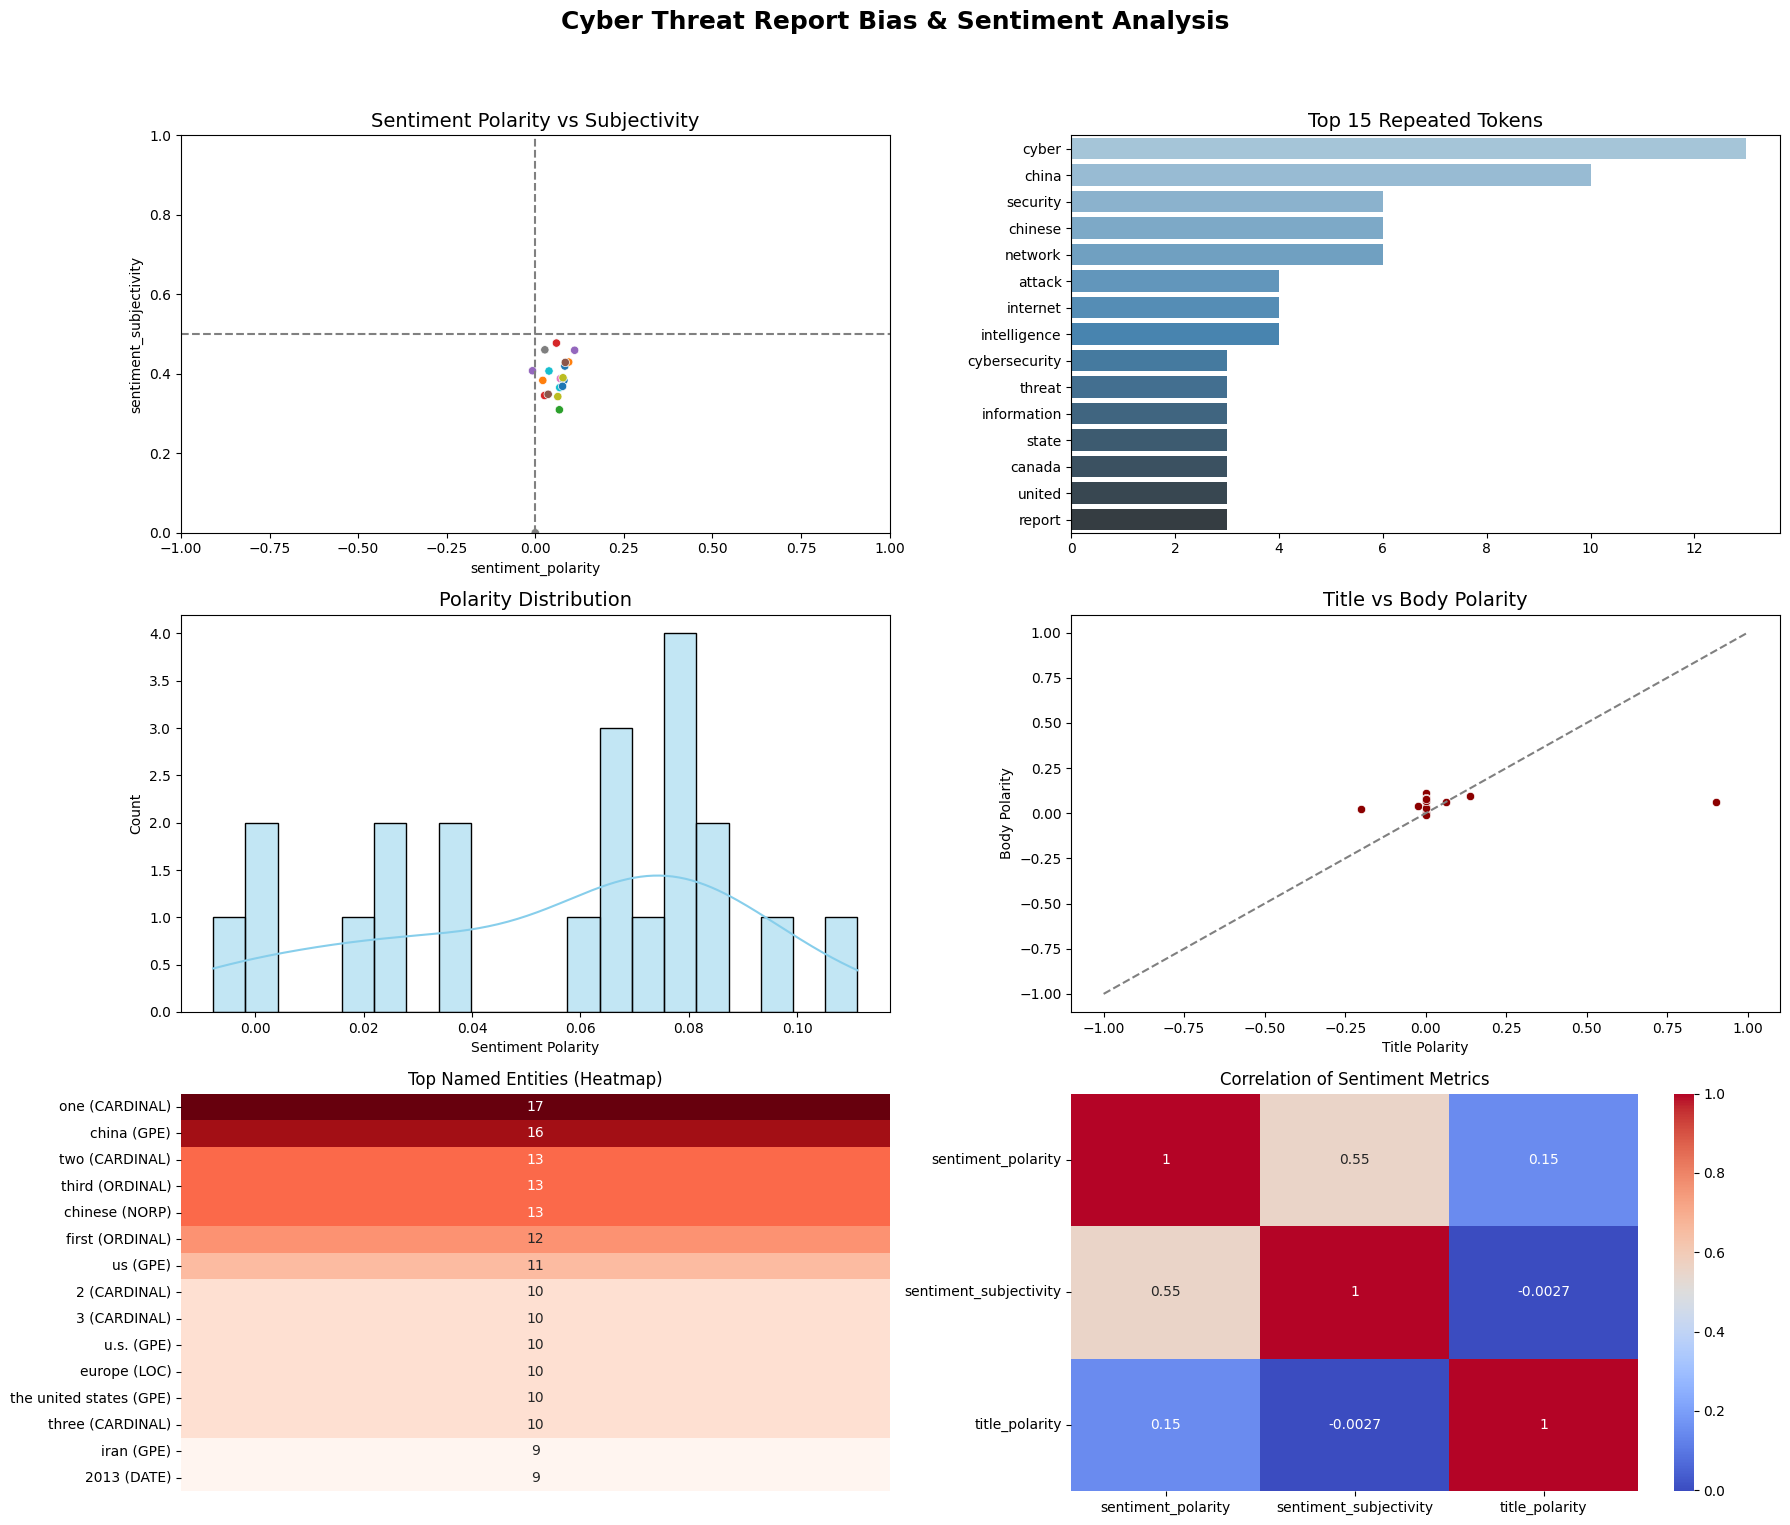

In [15]:
if __name__ == "__main__":
    #downloading my three additional articles
    download_pdf("https://canadiancybersecuritynetwork.com/hubfs/CS-Report-CCN-2025-All-v10.pdf")
    download_pdf("https://go.recordedfuture.com/hubfs/reports/cta-2023-1107.pdf")
    download_pdf("https://www.clairfield.com/wp-content/uploads/2025/06/Clairfield-International-cybersecurity-report-2024-2025.pdf")
    df = load_data(data_dir)
    columns_to_drop = ["text", "cleaned_text", "section_labels"]
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    display(df)
    df.to_csv(output_dir + "report.csv", index=False)
    plot_bias_report(df, output_dir + "plot.png")


# This concludes Project 3a.